In [1]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”


In [2]:
RNA.cov <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/covariates/Hepatocytes_perdonor.RNA.covariates.tsv')
RNA.cov <- t(RNA.cov) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
dim(RNA.cov)
head(RNA.cov)

[1] 86 32

,donor,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,feature.PC2,feature.PC3,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL160042,1,-0.98046310,-0.79714000,0,2,1,-93.36481,22.83019,-19.339760,⋯,-0.0111287,0.00380533,0.03954220,-0.006265730,-0.00386021,0.00771307,-1.75643e-03,-0.00687415,0.010761400,9.66876e-03
2,HL170046,1,0.42981569,2.13084844,1,3,1,-99.63055,56.33456,-4.224733,⋯,-0.0129588,0.02662470,-0.00340496,0.018265600,-0.00287539,-0.01398610,1.23325e-04,0.00230401,-0.000287042,3.55590e-03
3,HL190326,1,-0.46088670,-0.83281495,0,2,1,-60.29139,52.91906,28.059599,⋯,-0.0147062,-0.01295160,0.07529630,-0.023607700,-0.00132704,-0.00595419,-4.31907e-05,-0.00304233,0.014321600,1.92004e-04
4,HL160029,1,-0.01553551,-0.14177796,0,1,1,-79.17290,76.26758,11.350735,⋯,-0.0104861,0.00707262,0.03083550,0.000670898,-0.00198687,0.01476340,-3.75507e-03,-0.00198251,0.009025750,8.66651e-04
5,HL170060,1,0.20714009,-0.28183517,2,4,1,-50.97397,33.37821,-45.973181,⋯,-0.0123151,0.02658660,-0.00395044,0.017962300,-0.00193481,-0.01443590,-5.57276e-04,0.00147937,-0.000147571,1.69406e-05
6,HL210120,2,0.28136529,-0.02550406,3,4,1,-95.66030,-13.40454,-17.995776,⋯,-0.0117391,0.02623390,-0.00275870,0.017713800,-0.00230536,0.00284170,-2.35794e-03,0.00316974,-0.000331108,1.50624e-03


In [3]:
RNA.counts <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/counts/Hepatocytes_perdonor.RNA.INT.bed')

dim(RNA.counts)
head(RNA.counts)

[1] 20235    90

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,⋯,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90
,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1,133722,133723,AL627309.1,-1.6227112,0.5344601,-1.10897293,-1.2240583,0.60299558,-0.1906023,⋯,0.8710608,-1.8946444,-0.2805315,-2.5232398,-0.01457394,-1.3581421,0.3417246,-0.0437342,1.0565923,0.7887938
2,chr1,173861,173862,AL627309.5,-1.4354364,0.7115489,0.34172462,-0.6029956,-0.01457394,1.0565923,⋯,-0.1610005,-1.1089729,-0.3417246,-0.0437342,-0.22037207,-0.8710608,-1.2240583,-0.6383347,1.6227112,0.0437342
3,chr1,778746,778747,LINC01409,-1.4354364,-0.9596939,-1.35814208,-1.0565923,-0.04373420,0.3727933,⋯,0.6029956,-2.5232398,-0.2805315,0.1315391,-0.13153913,1.2240583,1.5224076,1.6227112,-0.6744898,0.4683492
4,chr1,825137,825138,LINC01128,-0.5011308,1.4354364,1.00696106,0.9596939,-0.07293170,0.2203721,⋯,0.6383347,-0.1610005,-0.9144792,0.3109825,-0.82922563,2.1097056,0.0437342,-0.8710608,-0.2503385,-0.3109825
5,chr1,827521,827522,LINC00115,-1.2240583,-1.7426467,-1.89464435,-1.1645874,-0.13153913,-0.8710608,⋯,0.6744898,0.1906023,0.1021915,-0.8292256,2.10970561,0.5344601,1.2240583,-0.4042260,-0.2503385,0.7496121
6,chr1,876902,876903,FAM41C,-1.1089729,-0.9596939,-0.01457394,-0.6744898,-1.89464435,1.0565923,⋯,1.0069611,1.5224076,-0.1315391,-1.5224076,0.28053149,0.7115489,1.1089729,0.4683492,-0.1021915,0.4360634


In [4]:
vcf.df <- data.table::fread('/nfs/lab/tscc/welison/FNIH.Liver/genotypes/241009_WE_class_matrix.rsID.tsv')
vcf.df <- tibble::column_to_rownames(vcf.df, 'V1')


#rownames(vcf.df) <- NULL
#vcf.df <- tibble::column_to_rownames(vcf.df, 'ID')

dim(vcf.df)
head(vcf.df)

Warning message in data.table::fread("/nfs/lab/tscc/welison/FNIH.Liver/genotypes/241009_WE_class_matrix.rsID.tsv"):
“Detected 87 column names but the data has 88 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


[1] 5492117      87

,ID,HL170044,HL200529,HL230212,HL220405,HL160017,HL170064,HL220402,HL150015,HL181029,⋯,HL170066,HL180071,HL170060,HL211122,HL221215,HL210806,HL190606,HL191216,HL210120,HL181010
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
chr10:116162:A:C,rs11594819,1,1,0,1,0,0,1,1,1,⋯,1,1,2,1,0,2,1,2,2,0
chr10:125824:C:G,rs72770958,1,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr10:132494:T:G,rs7089889,2,1,2,1,2,2,2,2,1,⋯,0,1,1,1,2,2,1,1,1,2
chr10:136160:C:T,rs73581705,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1
chr10:142865:A:G,rs12146291,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1
chr10:155638:G:A,rs17156310,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1


In [5]:
RNA.feat.counts <- filter(RNA.counts, V4=='EFHD1') %>%
    select(-V1, -V2, -V3) %>%
    tibble::column_to_rownames('V4')
colnames(RNA.feat.counts) <- RNA.cov$donor
RNA.feat.counts <- t(RNA.feat.counts) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
RNA.feat.counts

donor,EFHD1
<chr>,<dbl>
HL160042,-0.46834921
HL170046,0.74961208
HL190326,0.95969388
HL160029,0.34172462
HL170060,-0.78879376
HL210120,-1.62271117
HL200925,-0.91447917
HL230316,0.50113080
HL220825,1.52240762


In [107]:
filter(vcf.df, ID=='rs7604422')

,ID,HL170044,HL200529,HL230212,HL220405,HL160017,HL170064,HL220402,HL150015,HL181029,⋯,HL170066,HL180071,HL170060,HL211122,HL221215,HL210806,HL190606,HL191216,HL210120,HL181010
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
chr2:232645051:C:A,rs7604422,1,0,0,1,2,1,2,2,2,⋯,1,0,1,1,1,1,0,1,0,1


In [108]:
RNA.snp.df <- filter(vcf.df, ID=='rs7604422') %>%
    select(-ID) 
rownames(RNA.snp.df) <- 'variant'
RNA.snp.df <- t(RNA.snp.df) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
#RNA.snp.df$variant <- factor(RNA.snp.df$variant, levels=0:2)
RNA.snp.df

donor,variant
<chr>,<int>
HL170044,1
HL200529,0
HL230212,0
HL220405,1
HL160017,2
HL170064,1
HL220402,2
HL150015,2
HL181029,2


In [109]:
inner_join(RNA.snp.df, RNA.feat.counts)

Joining with `by = join_by(donor)`


donor,variant,EFHD1
<chr>,<int>,<dbl>
HL170044,1,0.60299558
HL200529,0,-1.89464435
HL230212,0,-1.74264669
HL220405,1,-0.25033851
HL160017,2,1.35814208
HL170064,1,-0.19060227
HL220402,2,2.52323982
HL150015,2,0.37279325
HL181029,2,-0.56839403


In [111]:
broom::tidy(lm(EFHD1~variant, data = inner_join(RNA.snp.df, RNA.feat.counts)))

Joining with `by = join_by(donor)`


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.9497499,0.1308948,-7.255827,1.829878e-10
variant,0.9723630,0.1081400,8.991706,6.166211e-14


In [112]:
test.data <- inner_join(RNA.snp.df, RNA.feat.counts) %>%
    inner_join(RNA.cov)
dim(test.data)
head(test.data)

Joining with `by = join_by(donor)`
Joining with `by = join_by(donor)`


[1] 86 34

,donor,variant,EFHD1,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL170044,1,0.6029956,2,-0.01553551,0.11455315,0,1,2,-10.97471,⋯,-0.0128442,0.017314500,-0.00276722,0.01341930,-0.00297114,-0.03327060,0.005593500,-0.007237180,0.003674560,-0.00228430
2,HL200529,0,-1.8946444,2,1.09784249,0.33388803,1,3,4,35.75990,⋯,-0.0101794,0.003793630,0.04251670,-0.00601031,-0.00585492,0.01142840,-0.000537141,-0.026803600,0.419668000,-0.54326300
3,HL230212,0,-1.7426467,2,0.65249129,0.03527549,1,3,3,55.22479,⋯,-0.0115252,0.002709290,0.04027980,-0.00646665,-0.00351872,0.00984427,-0.001876060,-0.002809980,0.007649630,0.00898169
4,HL220405,1,-0.2503385,2,-1.05468830,-0.81431682,0,2,4,72.83281,⋯,-0.0129373,0.027256000,-0.00437228,0.01950440,-0.00512447,-0.02138940,0.001285220,0.002518370,-0.025815600,0.01340040
5,HL160017,2,1.3581421,2,-1.20313870,-1.04818594,2,4,4,38.41884,⋯,-0.0127687,0.026879400,-0.00358643,0.01741510,-0.00204888,-0.01008540,-0.001203540,0.000274721,-0.000784055,-0.00173246
6,HL170064,1,-0.1906023,2,1.39474329,0.67346069,1,3,3,27.00254,⋯,0.0436429,0.000511416,0.00306145,0.00354503,0.00831225,-0.01237850,-0.025290500,0.000778331,-0.018317700,-0.00823998


In [113]:
colnames(test.data)

[1] "donor"          "variant"        "EFHD1"          "Gender"        
 [5] "Age.scaled"     "BMI.scaled"     "Fibrosis.stage" "condition"     
 [9] "batch"          "feature.PC1"    "feature.PC2"    "feature.PC3"   
[13] "feature.PC4"    "feature.PC5"    "feature.PC6"    "feature.PC7"   
[17] "feature.PC8"    "feature.PC9"    "feature.PC10"   "feature.PC11"  
[21] "feature.PC12"   "feature.PC13"   "feature.PC14"   "feature.PC15"  
[25] "genotype.PC1"   "genotype.PC2"   "genotype.PC3"   "genotype.PC4"  
[29] "genotype.PC5"   "genotype.PC6"   "genotype.PC7"   "genotype.PC8"  
[33] "genotype.PC9"   "genotype.PC10"

In [114]:
broom::tidy(lm(EFHD1~variant + Gender + Age.scaled + BMI.scaled + condition + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * condition, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.781797751,0.75769451,-1.03181129,3.058164e-01
variant,1.291774837,0.29557433,4.37038917,4.348631e-05
Gender,-0.010282023,0.17162242,-0.05991072,9.524025e-01
Age.scaled,-0.207987106,0.09038938,-2.30101261,2.446270e-02
BMI.scaled,-0.005042471,0.08885660,-0.05674841,9.549120e-01
condition,-0.003851726,0.13787608,-0.02793615,9.777949e-01
batch,-0.038502380,0.08150756,-0.47237799,6.381695e-01
genotype.PC1,15.241981938,19.91998200,0.76516043,4.468236e-01
genotype.PC2,3.286255507,8.50359867,0.38645468,7.003666e-01


In [115]:
broom::tidy(lm(EFHD1~variant + Gender + Age.scaled + BMI.scaled + Fibrosis.stage + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * Fibrosis.stage, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.62875566,0.63402376,-0.99169102,3.248640e-01
variant,1.05525026,0.13876027,7.60484469,1.143110e-10
Gender,-0.01405654,0.16382250,-0.08580346,9.318748e-01
Age.scaled,-0.17606901,0.08752366,-2.01167324,4.821927e-02
BMI.scaled,-0.04315622,0.08376402,-0.51521193,6.080758e-01
Fibrosis.stage,-0.04853979,0.09409913,-0.51583673,6.076417e-01
batch,-0.05173686,0.07705626,-0.67141668,5.042297e-01
genotype.PC1,15.39430087,19.04696564,0.80822852,4.217776e-01
genotype.PC2,4.58268032,8.18186550,0.56010213,5.772504e-01


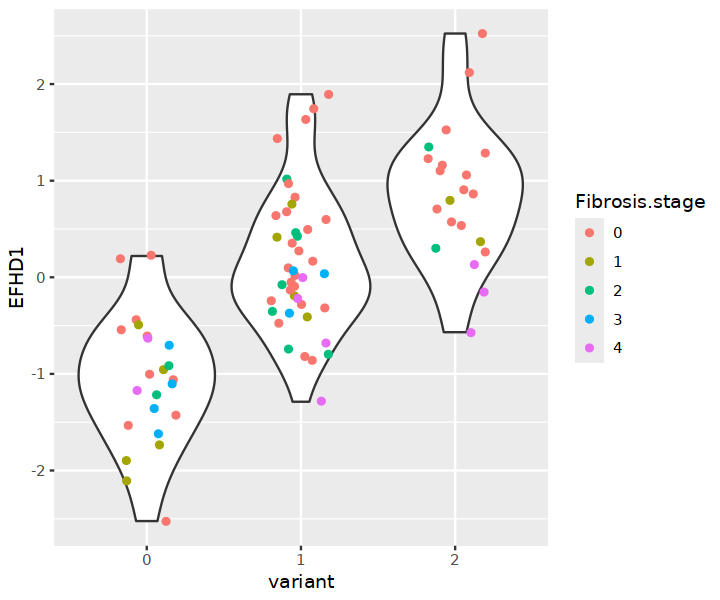

In [116]:
plot.data <- test.data
plot.data$variant <- factor(plot.data$variant, levels=0:2)
plot.data$Fibrosis.stage <- factor(plot.data$Fibrosis.stage, levels=0:4)

ggplot(plot.data, aes(x=variant, y=EFHD1)) + geom_violin() +
    geom_jitter(aes(color=Fibrosis.stage), width=.2)

In [15]:
ATAC.cov <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/covariates/Hepatocytes_perdonor.ATAC.covariates.tsv')
ATAC.cov <- t(ATAC.cov) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
dim(ATAC.cov)
head(ATAC.cov)

[1] 86 32

,donor,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,feature.PC2,feature.PC3,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL160042,1,-0.98046310,-0.79714000,0,2,1,-457.27754,141.13913,-70.877444,⋯,-0.0111287,0.00380533,0.03954220,-0.006265730,-0.00386021,0.00771307,-1.75643e-03,-0.00687415,0.010761400,9.66876e-03
2,HL170046,1,0.42981569,2.13084844,1,3,1,-167.73803,111.78329,-11.566328,⋯,-0.0129588,0.02662470,-0.00340496,0.018265600,-0.00287539,-0.01398610,1.23325e-04,0.00230401,-0.000287042,3.55590e-03
3,HL190326,1,-0.46088670,-0.83281495,0,2,1,-238.15402,85.65613,9.323528,⋯,-0.0147062,-0.01295160,0.07529630,-0.023607700,-0.00132704,-0.00595419,-4.31907e-05,-0.00304233,0.014321600,1.92004e-04
4,HL160029,1,-0.01553551,-0.14177796,0,1,1,-465.79738,15.37536,72.397304,⋯,-0.0104861,0.00707262,0.03083550,0.000670898,-0.00198687,0.01476340,-3.75507e-03,-0.00198251,0.009025750,8.66651e-04
5,HL170060,1,0.20714009,-0.28183517,2,4,1,-425.73998,-48.49428,-67.966397,⋯,-0.0123151,0.02658660,-0.00395044,0.017962300,-0.00193481,-0.01443590,-5.57276e-04,0.00147937,-0.000147571,1.69406e-05
6,HL210120,2,0.28136529,-0.02550406,3,4,1,-41.16738,337.79970,-142.628421,⋯,-0.0117391,0.02623390,-0.00275870,0.017713800,-0.00230536,0.00284170,-2.35794e-03,0.00316974,-0.000331108,1.50624e-03


In [16]:
ATAC.counts <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/counts/Hepatocytes_perdonor.ATAC.INT.bed')

dim(ATAC.counts)
head(ATAC.counts)

[1] 549326     90

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,⋯,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90
,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1,1000018,1000318,chr1-1000018-1000318,1.4354364,1.6227112,0.8292256,0.9144792,1.5224076,1.7426467,⋯,-0.1906023,0.7496121,-0.6744898,0.9596939,-0.5011308,-0.2805315,-0.2503385,0.1906023,-1.358142,0.0729317
2,chr1,100002909,100003209,chr1-100002909-100003209,-0.3417246,-0.4360634,0.2203721,-0.2805315,-1.6796612,-1.2882056,⋯,0.6744898,-0.3109825,0.7115489,1.8946444,0.5344601,0.6029956,0.8292256,-0.4042260,-1.679661,1.3581421
3,chr1,100006468,100006768,chr1-100006468-100006768,1.0069611,0.6383347,-0.1906023,0.2805315,1.8946444,-0.9144792,⋯,0.9596939,-1.7426467,0.3109825,0.8710608,0.1610005,0.0729317,-0.6383347,-1.2240583,1.056592,-1.0069611
4,chr1,100027262,100027562,chr1-100027262-100027562,2.5232398,-1.4354364,-0.4042260,-0.1315391,0.7496121,0.3109825,⋯,-1.2240583,-0.8292256,0.8710608,-0.3109825,0.2503385,0.2805315,1.6227112,0.7115489,2.109706,0.8292256
5,chr1,100028816,100029116,chr1-100028816-100029116,-0.7115489,-0.3727933,-0.5344601,-1.4354364,0.1315391,0.2503385,⋯,-1.5224076,-0.6744898,-0.4042260,-0.0437342,-0.4683492,0.6744898,0.5683940,-0.8292256,-1.894644,0.9596939
6,chr1,1000344,1000644,chr1-1000344-1000644,0.6744898,1.6227112,0.6029956,0.6383347,0.2203721,2.1097056,⋯,-0.3727933,1.1645874,-0.5683940,0.3109825,-1.1645874,0.1906023,-0.0437342,0.2805315,-2.523240,-0.4683492


In [17]:
ATAC.feat.counts <- filter(ATAC.counts, V4=='chr2-232647251-232647551') %>%
    select(-V1, -V2, -V3) %>%
    tibble::column_to_rownames('V4')
colnames(ATAC.feat.counts) <- ATAC.cov$donor
ATAC.feat.counts <- t(ATAC.feat.counts) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
ATAC.feat.counts

donor,chr2-232647251-232647551
<chr>,<dbl>
HL160042,0.5683940
HL170046,1.0565923
HL190326,1.8946444
HL160029,1.1089729
HL170060,0.5344601
HL210120,-1.3581421
HL200925,-1.0069611
HL230316,0.8292256
HL220825,2.5232398


In [117]:
ATAC.snp.df <- filter(vcf.df, ID=='rs7604422') %>%
    select(-ID) 
rownames(ATAC.snp.df) <- 'variant'
ATAC.snp.df <- t(ATAC.snp.df) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
#ATAC.snp.df$variant <- factor(ATAC.snp.df$variant, levels=0:2)
ATAC.snp.df

donor,variant
<chr>,<int>
HL170044,1
HL200529,0
HL230212,0
HL220405,1
HL160017,2
HL170064,1
HL220402,2
HL150015,2
HL181029,2


In [118]:
inner_join(ATAC.snp.df, ATAC.feat.counts)

Joining with `by = join_by(donor)`


donor,variant,chr2-232647251-232647551
<chr>,<int>,<dbl>
HL170044,1,-0.10219153
HL200529,0,-1.05659235
HL230212,0,-1.74264669
HL220405,1,0.16100048
HL160017,2,2.10970561
HL170064,1,0.10219153
HL220402,2,1.35814208
HL150015,2,0.78879376
HL181029,2,-0.53446009


In [120]:
broom::tidy(lm(`chr2-232647251-232647551`~variant, data = inner_join(ATAC.snp.df, ATAC.feat.counts)))

Joining with `by = join_by(donor)`


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.9942777,0.1247031,-7.973159,6.864260e-12
variant,1.0179510,0.1030247,9.880652,1.007378e-15


In [121]:
test.data <- inner_join(ATAC.snp.df, ATAC.feat.counts) %>%
    inner_join(ATAC.cov)
dim(test.data)
head(test.data)

Joining with `by = join_by(donor)`
Joining with `by = join_by(donor)`


[1] 86 34

,donor,variant,chr2-232647251-232647551,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL170044,1,-0.1021915,2,-0.01553551,0.11455315,0,1,2,113.51412,⋯,-0.0128442,0.017314500,-0.00276722,0.01341930,-0.00297114,-0.03327060,0.005593500,-0.007237180,0.003674560,-0.00228430
2,HL200529,0,-1.0565923,2,1.09784249,0.33388803,1,3,4,20.62397,⋯,-0.0101794,0.003793630,0.04251670,-0.00601031,-0.00585492,0.01142840,-0.000537141,-0.026803600,0.419668000,-0.54326300
3,HL230212,0,-1.7426467,2,0.65249129,0.03527549,1,3,3,157.87010,⋯,-0.0115252,0.002709290,0.04027980,-0.00646665,-0.00351872,0.00984427,-0.001876060,-0.002809980,0.007649630,0.00898169
4,HL220405,1,0.1610005,2,-1.05468830,-0.81431682,0,2,4,41.89470,⋯,-0.0129373,0.027256000,-0.00437228,0.01950440,-0.00512447,-0.02138940,0.001285220,0.002518370,-0.025815600,0.01340040
5,HL160017,2,2.1097056,2,-1.20313870,-1.04818594,2,4,4,-227.75646,⋯,-0.0127687,0.026879400,-0.00358643,0.01741510,-0.00204888,-0.01008540,-0.001203540,0.000274721,-0.000784055,-0.00173246
6,HL170064,1,0.1021915,2,1.39474329,0.67346069,1,3,3,78.13143,⋯,0.0436429,0.000511416,0.00306145,0.00354503,0.00831225,-0.01237850,-0.025290500,0.000778331,-0.018317700,-0.00823998


In [122]:
colnames(test.data)

[1] "donor"                    "variant"                 
 [3] "chr2-232647251-232647551" "Gender"                  
 [5] "Age.scaled"               "BMI.scaled"              
 [7] "Fibrosis.stage"           "condition"               
 [9] "batch"                    "feature.PC1"             
[11] "feature.PC2"              "feature.PC3"             
[13] "feature.PC4"              "feature.PC5"             
[15] "feature.PC6"              "feature.PC7"             
[17] "feature.PC8"              "feature.PC9"             
[19] "feature.PC10"             "feature.PC11"            
[21] "feature.PC12"             "feature.PC13"            
[23] "feature.PC14"             "feature.PC15"            
[25] "genotype.PC1"             "genotype.PC2"            
[27] "genotype.PC3"             "genotype.PC4"            
[29] "genotype.PC5"             "genotype.PC6"            
[31] "genotype.PC7"             "genotype.PC8"            
[33] "genotype.PC9"             "genotype.PC10"

In [123]:
broom::tidy(lm(`chr2-232647251-232647551`~variant + Gender + Age.scaled + BMI.scaled + Fibrosis.stage + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * Fibrosis.stage, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.188492113,0.63366925,-0.29746135,7.670212e-01
variant,0.994883714,0.13868268,7.17381373,6.892804e-10
Gender,0.008726575,0.16373090,0.05329828,9.576505e-01
Age.scaled,-0.068935453,0.08747472,-0.78806139,4.333994e-01
BMI.scaled,-0.097199527,0.08371718,-1.16104631,2.496827e-01
Fibrosis.stage,-0.165055166,0.09404651,-1.75503763,8.375699e-02
batch,-0.146269668,0.07701318,-1.89928104,6.177019e-02
genotype.PC1,-0.682549798,19.03631592,-0.03585514,9.715029e-01
genotype.PC2,2.493031688,8.17729077,0.30487257,7.613944e-01


In [124]:
broom::tidy(lm(`chr2-232647251-232647551`~variant + Gender + Age.scaled + BMI.scaled + condition + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * condition, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.03059657,0.76460549,-0.04001616,0.968197503
variant,0.89146026,0.29827028,2.98876662,0.003895363
Gender,0.01513187,0.17318780,0.08737260,0.930632136
Age.scaled,-0.10354445,0.09121383,-1.13518371,0.260283837
BMI.scaled,-0.08036152,0.08966707,-0.89622109,0.373296513
condition,-0.13259338,0.13913366,-0.95299286,0.343969053
batch,-0.12850238,0.08225100,-1.56232003,0.122854891
genotype.PC1,-0.63064983,20.10167345,-0.03137300,0.975063974
genotype.PC2,0.70186472,8.58116055,0.08179135,0.935052906


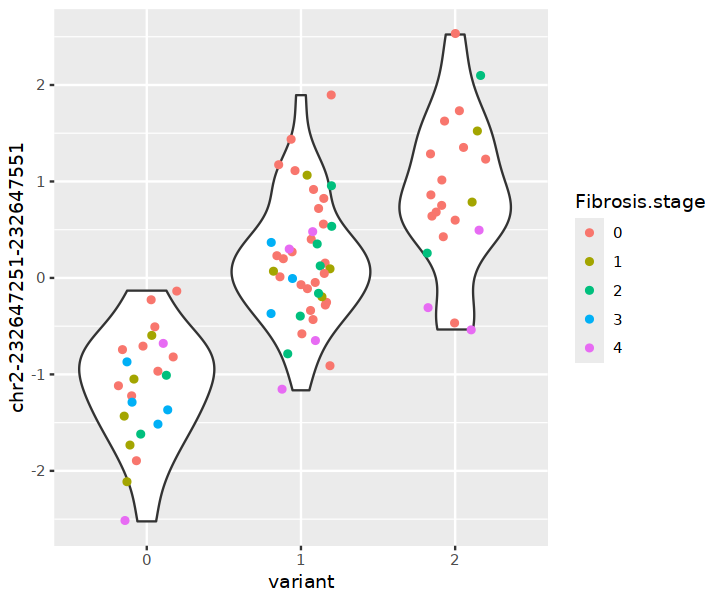

In [125]:
plot.data <- test.data
plot.data$variant <- factor(plot.data$variant, levels=0:2)
plot.data$Fibrosis.stage <- factor(plot.data$Fibrosis.stage, levels=0:4)

ggplot(plot.data, aes(x=variant, y=`chr2-232647251-232647551`)) + geom_violin() +
    geom_jitter(aes(color=Fibrosis.stage), width=.2)

In [26]:
RNA.CPM <- read.table('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/Hepatocytes_perdonor.RNA.CPM.tsv')

dim(RNA.CPM)
head(RNA.CPM)

[1] 36601    86

,HL160042,HL170046,HL190326,HL160029,HL170060,HL210120,HL200925,HL230316,HL220825,HL191025,⋯,HL160026,HL190827,HL150015,HL200529,HL211001,HL210706,HL211025,HL150009,HL201024,HL200212
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MIR1302-2HG,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.00000,0.000000,0.0000000,0.0000000,0.2179387,⋯,0.05977362,0.0000000,0.00000000,0.0000000,0.00000000,0.000000,0.05585997,0.06375418,0.000000,0.00000000
FAM138A,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.00000,0.000000,0.0000000,0.0000000,0.0000000,⋯,0.00000000,0.0000000,0.00000000,0.0000000,0.00000000,0.000000,0.00000000,0.00000000,0.000000,0.00000000
OR4F5,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.00000,0.000000,0.0000000,0.3329151,0.0000000,⋯,0.00000000,0.0000000,0.00000000,0.0000000,0.00000000,0.000000,0.00000000,0.00000000,0.000000,0.00000000
AL627309.1,0.8293026,3.0924675,1.201489,1.3701236,2.819603,1.93863,2.929632,0.7331914,4.6608111,0.8717546,⋯,2.80936025,0.5103315,1.50606098,0.2747235,1.77784291,0.814382,2.23439895,1.78511716,2.907761,2.83855707
AL627309.3,0.4146513,0.3255229,0.252945,0.3914639,0.000000,0.00000,0.000000,0.0000000,0.0000000,0.0000000,⋯,0.05977362,0.0000000,0.03274046,0.0000000,0.03782644,0.000000,0.00000000,0.00000000,0.000000,0.06758469
AL627309.2,0.0000000,0.0000000,0.000000,0.0000000,0.000000,0.00000,0.000000,0.0000000,0.0000000,0.0000000,⋯,0.00000000,0.0000000,0.00000000,0.0000000,0.00000000,0.000000,0.00000000,0.00000000,0.000000,0.00000000


In [27]:
RNA.feat.CPM <- RNA.CPM['EFHD1',] 
RNA.feat.CPM <- t(RNA.feat.CPM) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
RNA.feat.CPM

donor,EFHD1
<chr>,<dbl>
HL160042,15.342098
HL170046,57.292030
HL190326,62.224480
HL160029,34.448823
HL170060,9.398676
HL210120,3.649187
HL200925,9.486427
HL230316,39.683984
HL220825,135.496438


In [135]:
RNA.snp.df <- filter(vcf.df, ID=='rs7604422') %>%
    select(-ID) 
rownames(RNA.snp.df) <- 'variant'
RNA.snp.df <- t(RNA.snp.df) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
#RNA.snp.df$variant <- factor(RNA.snp.df$variant, levels=0:2)
RNA.snp.df

donor,variant
<chr>,<int>
HL170044,1
HL200529,0
HL230212,0
HL220405,1
HL160017,2
HL170064,1
HL220402,2
HL150015,2
HL181029,2


In [136]:
inner_join(RNA.snp.df, RNA.feat.CPM)

Joining with `by = join_by(donor)`


donor,variant,EFHD1
<chr>,<int>,<dbl>
HL170044,1,39.153705
HL200529,0,1.991745
HL230212,0,2.576575
HL220405,1,15.853010
HL160017,2,67.898635
HL170064,1,16.909301
HL220402,2,178.578904
HL150015,2,26.519769
HL181029,2,12.980969


Joining with `by = join_by(donor)`


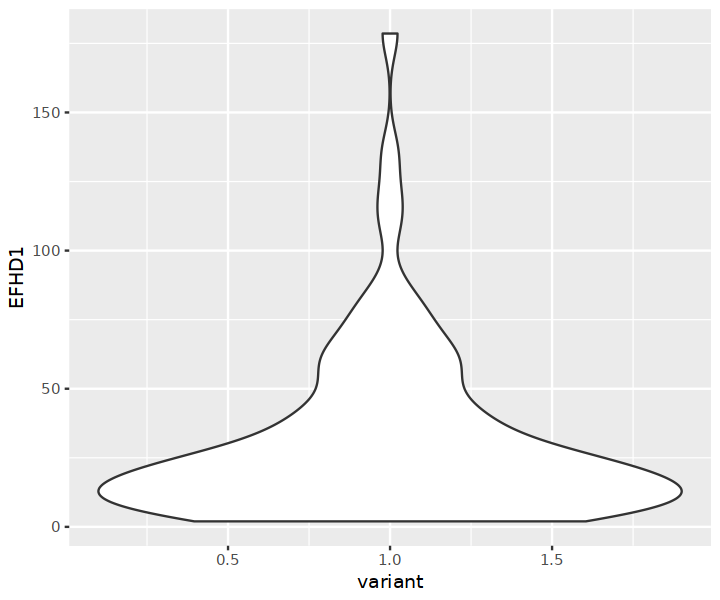

In [137]:
ggplot(inner_join(RNA.snp.df, RNA.feat.CPM), aes(x=variant, y=EFHD1)) + geom_violin()

In [138]:
broom::tidy(lm(EFHD1~variant, data = inner_join(RNA.snp.df, RNA.feat.CPM)))

Joining with `by = join_by(donor)`


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),6.44284,4.829959,1.333932,1.858314e-01
variant,25.38810,3.990317,6.362427,9.953787e-09


In [139]:
test.data <- inner_join(RNA.snp.df, RNA.feat.CPM) %>%
    inner_join(RNA.cov)
dim(test.data)
head(test.data)

Joining with `by = join_by(donor)`
Joining with `by = join_by(donor)`


[1] 86 34

,donor,variant,EFHD1,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL170044,1,39.153705,2,-0.01553551,0.11455315,0,1,2,-10.97471,⋯,-0.0128442,0.017314500,-0.00276722,0.01341930,-0.00297114,-0.03327060,0.005593500,-0.007237180,0.003674560,-0.00228430
2,HL200529,0,1.991745,2,1.09784249,0.33388803,1,3,4,35.75990,⋯,-0.0101794,0.003793630,0.04251670,-0.00601031,-0.00585492,0.01142840,-0.000537141,-0.026803600,0.419668000,-0.54326300
3,HL230212,0,2.576575,2,0.65249129,0.03527549,1,3,3,55.22479,⋯,-0.0115252,0.002709290,0.04027980,-0.00646665,-0.00351872,0.00984427,-0.001876060,-0.002809980,0.007649630,0.00898169
4,HL220405,1,15.853010,2,-1.05468830,-0.81431682,0,2,4,72.83281,⋯,-0.0129373,0.027256000,-0.00437228,0.01950440,-0.00512447,-0.02138940,0.001285220,0.002518370,-0.025815600,0.01340040
5,HL160017,2,67.898635,2,-1.20313870,-1.04818594,2,4,4,38.41884,⋯,-0.0127687,0.026879400,-0.00358643,0.01741510,-0.00204888,-0.01008540,-0.001203540,0.000274721,-0.000784055,-0.00173246
6,HL170064,1,16.909301,2,1.39474329,0.67346069,1,3,3,27.00254,⋯,0.0436429,0.000511416,0.00306145,0.00354503,0.00831225,-0.01237850,-0.025290500,0.000778331,-0.018317700,-0.00823998


In [140]:
colnames(test.data)

[1] "donor"          "variant"        "EFHD1"          "Gender"        
 [5] "Age.scaled"     "BMI.scaled"     "Fibrosis.stage" "condition"     
 [9] "batch"          "feature.PC1"    "feature.PC2"    "feature.PC3"   
[13] "feature.PC4"    "feature.PC5"    "feature.PC6"    "feature.PC7"   
[17] "feature.PC8"    "feature.PC9"    "feature.PC10"   "feature.PC11"  
[21] "feature.PC12"   "feature.PC13"   "feature.PC14"   "feature.PC15"  
[25] "genotype.PC1"   "genotype.PC2"   "genotype.PC3"   "genotype.PC4"  
[29] "genotype.PC5"   "genotype.PC6"   "genotype.PC7"   "genotype.PC8"  
[33] "genotype.PC9"   "genotype.PC10"

In [141]:
broom::tidy(lm(EFHD1~variant + Gender + Age.scaled + BMI.scaled + Fibrosis.stage + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * Fibrosis.stage, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),52.8790123,22.599482,2.33983291,2.223556e-02
variant,29.6950277,4.946045,6.00379225,8.374509e-08
Gender,-1.0890225,5.839377,-0.18649635,8.526108e-01
Age.scaled,-3.8091575,3.119740,-1.22098547,2.263082e-01
BMI.scaled,-3.0604365,2.985730,-1.02502134,3.089857e-01
Fibrosis.stage,-0.8008519,3.354120,-0.23876664,8.120047e-01
batch,-5.0318670,2.746635,-1.83201177,7.132917e-02
genotype.PC1,304.6597106,678.920242,0.44874153,6.550449e-01
genotype.PC2,295.6501589,291.638795,1.01375456,3.142935e-01


In [142]:
broom::tidy(lm(EFHD1~variant + Gender + Age.scaled + BMI.scaled + condition + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * condition, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),43.2398935,26.568608,1.62748057,0.1082602901
variant,42.5706330,10.364333,4.10741643,0.0001096969
Gender,-0.8688935,6.017952,-0.14438359,0.8856246398
Age.scaled,-4.9421300,3.169510,-1.55927274,0.1235741419
BMI.scaled,-1.3678750,3.115763,-0.43901770,0.6620405645
condition,1.0609605,4.834634,0.21945002,0.8269569132
batch,-4.6151785,2.858068,-1.61478953,0.1109872758
genotype.PC1,297.1322603,698.495487,0.42538895,0.6718964083
genotype.PC2,251.9623130,298.179250,0.84500284,0.4010726154


In [ ]:
	4.589131e-02

In [143]:
broom::tidy(lm(EFHD1~variant + Gender + Age.scaled + BMI.scaled + condition + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * condition, data = filter(test.data, condition != 4)))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),43.8940944,32.272031,1.3601280,0.1792398618
variant,49.4258306,13.215188,3.7400778,0.0004344994
Gender,-0.8364973,6.968168,-0.1200455,0.9048767512
Age.scaled,-3.8739149,3.557086,-1.0890698,0.2807877136
BMI.scaled,-0.3921056,3.575736,-0.1096573,0.9130731823
condition,2.3388505,6.777837,0.3450733,0.7313320281
batch,-6.6139267,3.267208,-2.0243359,0.0477152239
genotype.PC1,396.5405446,765.164471,0.5182422,0.6063309234
genotype.PC2,274.7856574,312.876303,0.8782565,0.3835572630


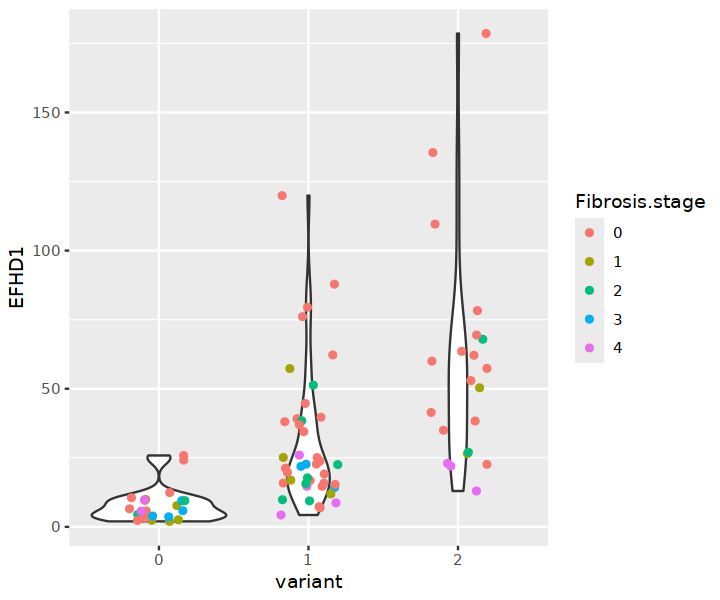

In [144]:
plot.data <- test.data
plot.data$variant <- factor(plot.data$variant, levels=0:2)
plot.data$Fibrosis.stage <- factor(plot.data$Fibrosis.stage, levels=0:4)

ggplot(plot.data, aes(x=variant, y=EFHD1)) + geom_violin() +
    geom_jitter(aes(color=Fibrosis.stage), width=.2)

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


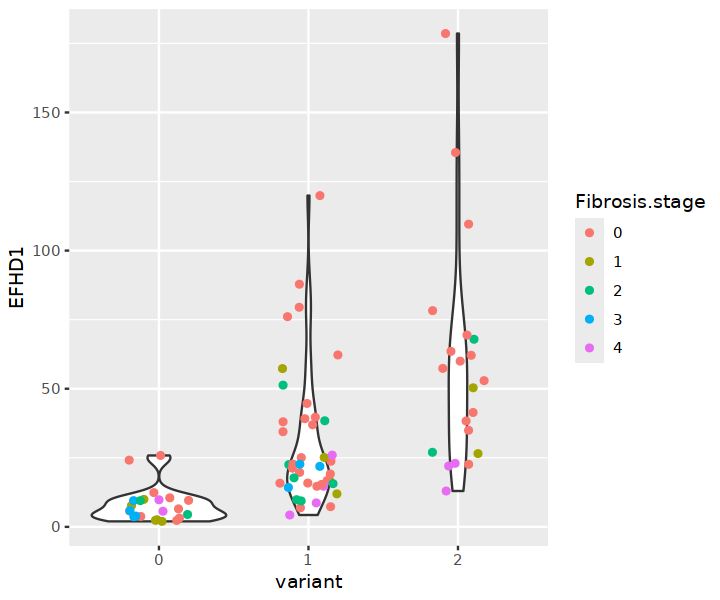

In [145]:
ggplot(plot.data, aes(x=variant, y=EFHD1)) + geom_violin() +
    geom_jitter(aes(color=Fibrosis.stage), width=.2) +
    geom_smooth()

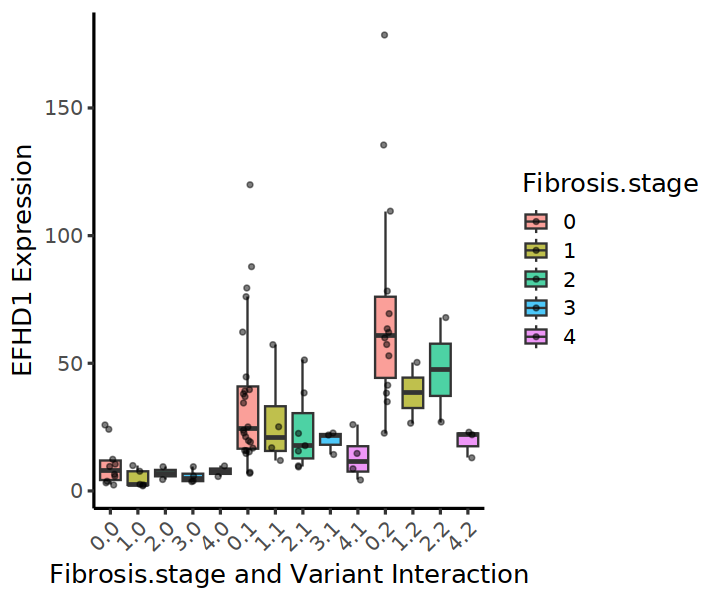

In [146]:
ggplot(test.data, aes(x = interaction(Fibrosis.stage, variant), y = EFHD1, fill = as.factor(Fibrosis.stage))) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +  # Boxplot
  geom_jitter(width = 0.2, alpha = 0.5, size = 1) +  # Add individual points
  labs(
    x = "Fibrosis.stage and Variant Interaction",
    y = "EFHD1 Expression",
    fill = "Fibrosis.stage"
  ) +
  theme_classic(base_size = 15) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)  # Rotate x-axis labels for readability
  )

png 
  2

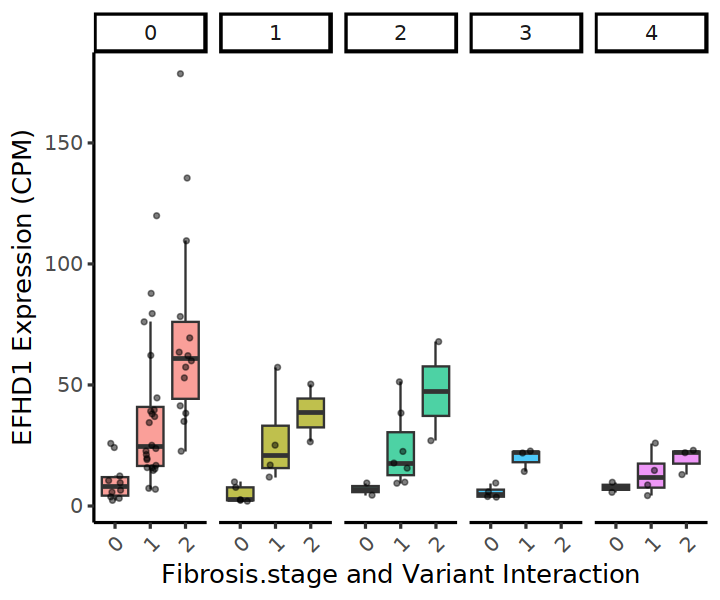

In [150]:
options(repr.plot.height=5, repr.plot.width=6)

p1 <- ggplot(test.data, aes(x = factor(variant, levels=0:2), y = EFHD1, fill = as.factor(Fibrosis.stage))) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +  # Boxplot
  geom_jitter(width = 0.2, alpha = 0.5, size = 1) +  # Add individual points
  labs(
    x = "Fibrosis.stage and Variant Interaction",
    y = "EFHD1 Expression (CPM)",
    fill = "Fibrosis.stage"
  ) +
  theme_classic(base_size = 15) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    legend.position='none'
  ) +
    facet_wrap(. ~ Fibrosis.stage, ncol=5) #+ geom_smooth(aes(x=variant), method='lm')

p1

pdf('/nfs/lab/welison/Liver/Plots/241222_WE_EFHD1_Interaction_Fibrosis.pdf', height=5, width=4)
p1
dev.off()

png 
  2

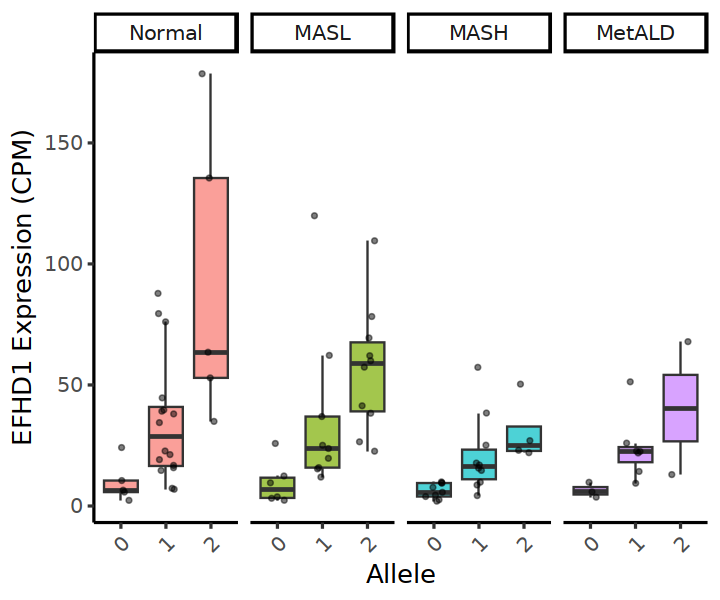

In [151]:
options(repr.plot.height=5, repr.plot.width=6)

test.data <- mutate(test.data, condition.factor=ifelse(condition==1, 'Normal',
                                                ifelse(condition==2, 'MASL',
                                                ifelse(condition==3, 'MASH','MetALD'))))
test.data <- mutate(test.data, condition.factor=factor(condition.factor, levels=c('Normal','MASL','MASH','MetALD')))

p1 <- ggplot(test.data, aes(x = factor(variant, levels=0:2), y = EFHD1, fill = condition.factor)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +  # Boxplot
  geom_jitter(width = 0.2, alpha = 0.5, size = 1) +  # Add individual points
  labs(
    x = "Allele",
    y = "EFHD1 Expression (CPM)",
    fill = "condition"
  ) +
  theme_classic(base_size = 15) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    legend.position='none'
  ) +
    facet_wrap(. ~ condition.factor, ncol=5) #+ geom_smooth(aes(x=variant), method='lm')

p1

pdf('/nfs/lab/welison/Liver/Plots/241222_WE_EFHD1_Interaction_condition.pdf', height=5, width=6)
p1
dev.off()

In [57]:
ATAC.CPM <- read.table('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hepatocytes_perdonor.ATAC.CPM.tsv')

dim(ATAC.CPM)
head(ATAC.CPM)

[1] 611576     86

,HL160042,HL170046,HL190326,HL160029,HL170060,HL210120,HL200925,HL230316,HL220825,HL191025,⋯,HL160026,HL190827,HL150015,HL200529,HL211001,HL210706,HL211025,HL150009,HL201024,HL200212
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1-9967-10267,1.5972419,1.49436847,1.2464263,1.0321372,1.07511330,3.27022052,1.98688106,2.68883446,0.9452695,2.2371375,⋯,2.38607392,1.7800169,2.9648458,3.6075123,1.3623125,2.2016163,2.7511434,4.5023508,3.9259846,1.6508786
chr1-16085-16372,0.2904076,0.22138792,0.2736058,0.3686204,0.31620979,0.43928335,0.82382873,0.75623469,0.3150898,0.4474275,⋯,0.25935586,0.0000000,0.6841952,0.1093186,0.1946161,0.2076997,0.9825512,0.1765628,0.2309403,0.4502396
chr1-17357-17657,0.2178057,0.38742886,0.5168109,0.3686204,0.56917763,0.87856671,0.87228925,1.00831292,0.0000000,0.6711412,⋯,0.36309820,0.7628644,1.2543578,0.6559113,0.3649051,0.5815590,0.6550341,0.9710953,1.8475221,0.4502396
chr1-29216-29497,0.0000000,0.00000000,0.0000000,0.0000000,0.06324196,0.00000000,0.00000000,0.05601738,0.0000000,0.0000000,⋯,0.05187117,0.0000000,0.0000000,0.1093186,0.0000000,0.0000000,0.1310068,0.0000000,0.0000000,0.0000000
chr1-102789-103089,1.3068343,2.37992016,2.0672435,0.8846890,4.42693710,4.63687984,1.50227592,2.52078231,3.1508984,2.2371375,⋯,1.40052165,2.7971694,1.5584446,1.7490969,1.2406774,2.2846962,3.4716809,1.7656277,1.6165819,2.0260783
chr1-136647-136947,0.0000000,0.05534698,0.0000000,0.0000000,0.06324196,0.04880926,0.04846051,0.00000000,0.0000000,0.0000000,⋯,0.00000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000


In [58]:
ATAC.feat.CPM <- ATAC.CPM['chr2-232647251-232647551',] 
ATAC.feat.CPM <- t(ATAC.feat.CPM) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
ATAC.feat.CPM

donor,chr2-232647251-232647551
<chr>,<dbl>
HL160042,5.2999392
HL170046,9.9624565
HL190326,13.4674837
HL160029,7.8147532
HL170060,5.2490826
HL210120,0.8785667
HL200925,1.2115128
HL230316,7.7864165
HL220825,32.4542537


In [59]:
ATAC.snp.df <- filter(vcf.df, ID=='rs7604500') %>%
    select(-ID) 
rownames(ATAC.snp.df) <- 'variant'
ATAC.snp.df <- t(ATAC.snp.df) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
#ATAC.snp.df$variant <- factor(ATAC.snp.df$variant, levels=0:2)
ATAC.snp.df

donor,variant
<chr>,<int>
HL170044,1
HL200529,0
HL230212,0
HL220405,1
HL160017,2
HL170064,1
HL220402,2
HL150015,2
HL181029,2


In [60]:
inner_join(ATAC.snp.df, ATAC.feat.CPM)

Joining with `by = join_by(donor)`


donor,variant,chr2-232647251-232647551
<chr>,<int>,<dbl>
HL170044,1,4.5337328
HL200529,0,1.4211412
HL230212,0,0.6731814
HL220405,1,5.2767005
HL160017,2,15.8082585
HL170064,1,5.2677658
HL220402,2,13.6482398
HL150015,2,9.9588411
HL181029,2,3.4086527


Joining with `by = join_by(donor)`


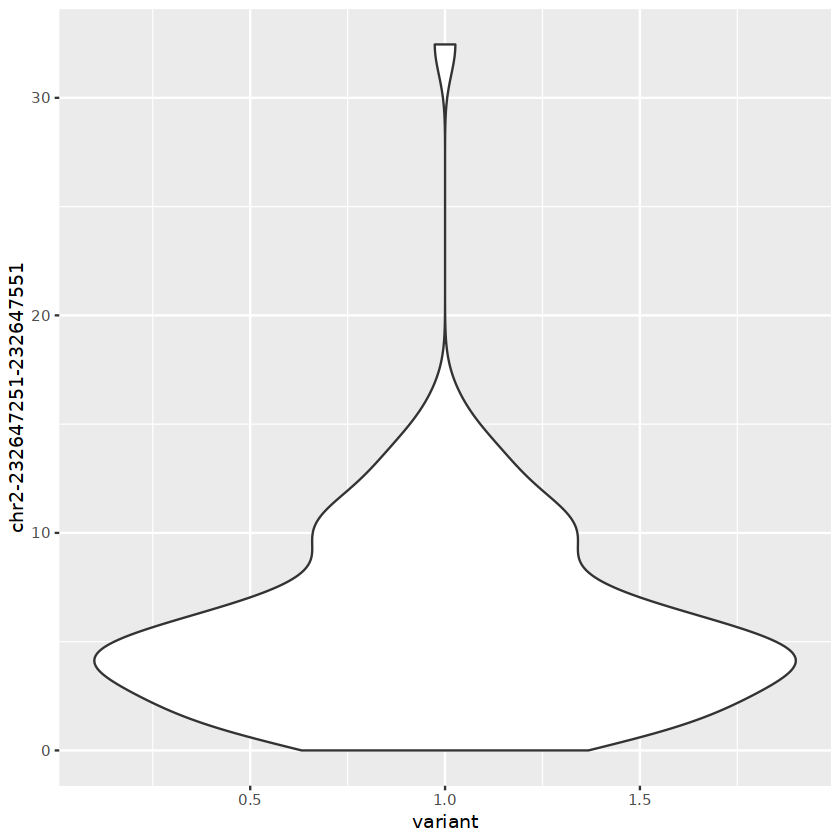

In [61]:
ggplot(inner_join(ATAC.snp.df, ATAC.feat.CPM), aes(x=variant, y=`chr2-232647251-232647551`)) + geom_violin()

In [62]:
broom::tidy(lm(`chr2-232647251-232647551`~variant, data = inner_join(ATAC.snp.df, ATAC.feat.CPM)))

Joining with `by = join_by(donor)`


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.286238,0.6884649,1.868269,6.521094e-02
variant,4.361523,0.5494955,7.937322,8.095922e-12


In [63]:
test.data <- inner_join(ATAC.snp.df, ATAC.feat.CPM) %>%
    inner_join(ATAC.cov)
dim(test.data)
head(test.data)

Joining with `by = join_by(donor)`
Joining with `by = join_by(donor)`


[1] 86 34

,donor,variant,chr2-232647251-232647551,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL170044,1,4.5337328,2,-0.01553551,0.11455315,0,1,2,113.51412,⋯,-0.0128442,0.017314500,-0.00276722,0.01341930,-0.00297114,-0.03327060,0.005593500,-0.007237180,0.003674560,-0.00228430
2,HL200529,0,1.4211412,2,1.09784249,0.33388803,1,3,4,20.62397,⋯,-0.0101794,0.003793630,0.04251670,-0.00601031,-0.00585492,0.01142840,-0.000537141,-0.026803600,0.419668000,-0.54326300
3,HL230212,0,0.6731814,2,0.65249129,0.03527549,1,3,3,157.87010,⋯,-0.0115252,0.002709290,0.04027980,-0.00646665,-0.00351872,0.00984427,-0.001876060,-0.002809980,0.007649630,0.00898169
4,HL220405,1,5.2767005,2,-1.05468830,-0.81431682,0,2,4,41.89470,⋯,-0.0129373,0.027256000,-0.00437228,0.01950440,-0.00512447,-0.02138940,0.001285220,0.002518370,-0.025815600,0.01340040
5,HL160017,2,15.8082585,2,-1.20313870,-1.04818594,2,4,4,-227.75646,⋯,-0.0127687,0.026879400,-0.00358643,0.01741510,-0.00204888,-0.01008540,-0.001203540,0.000274721,-0.000784055,-0.00173246
6,HL170064,1,5.2677658,2,1.39474329,0.67346069,1,3,3,78.13143,⋯,0.0436429,0.000511416,0.00306145,0.00354503,0.00831225,-0.01237850,-0.025290500,0.000778331,-0.018317700,-0.00823998


In [64]:
colnames(test.data)

[1] "donor"                    "variant"                 
 [3] "chr2-232647251-232647551" "Gender"                  
 [5] "Age.scaled"               "BMI.scaled"              
 [7] "Fibrosis.stage"           "condition"               
 [9] "batch"                    "feature.PC1"             
[11] "feature.PC2"              "feature.PC3"             
[13] "feature.PC4"              "feature.PC5"             
[15] "feature.PC6"              "feature.PC7"             
[17] "feature.PC8"              "feature.PC9"             
[19] "feature.PC10"             "feature.PC11"            
[21] "feature.PC12"             "feature.PC13"            
[23] "feature.PC14"             "feature.PC15"            
[25] "genotype.PC1"             "genotype.PC2"            
[27] "genotype.PC3"             "genotype.PC4"            
[29] "genotype.PC5"             "genotype.PC6"            
[31] "genotype.PC7"             "genotype.PC8"            
[33] "genotype.PC9"             "genotype.PC10"

In [65]:
broom::tidy(lm(`chr2-232647251-232647551`~variant + Gender + Age.scaled + BMI.scaled + Fibrosis.stage + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * Fibrosis.stage, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.192800e+01,3.0831605,3.868757180,2.475827e-04
variant,4.527819e+00,0.7061877,6.411636264,1.600851e-08
Gender,8.340741e-01,0.8017223,1.040352889,3.018609e-01
Age.scaled,-2.917428e-01,0.4247226,-0.686901986,4.944804e-01
BMI.scaled,-4.329059e-01,0.4054209,-1.067793718,2.893898e-01
Fibrosis.stage,1.554911e-03,0.4744363,0.003277386,9.973946e-01
batch,-7.399807e-01,0.3733105,-1.982212391,5.149842e-02
genotype.PC1,2.786749e+01,92.3526820,0.301750694,7.637630e-01
genotype.PC2,5.538799e+01,40.1491617,1.379555260,1.722435e-01


In [66]:
broom::tidy(lm(`chr2-232647251-232647551`~variant + Gender + Age.scaled + BMI.scaled + condition + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * condition, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),10.7663882,3.6801691,2.9255145,0.0046703089
variant,5.5041943,1.5016971,3.6653158,0.0004852828
Gender,0.7923856,0.8253968,0.9600057,0.3404535098
Age.scaled,-0.4139681,0.4322481,-0.9577096,0.3416019524
BMI.scaled,-0.3694168,0.4247571,-0.8697132,0.3875168275
condition,0.4416932,0.6972602,0.6334697,0.5285518910
batch,-0.6489403,0.3878171,-1.6733153,0.0988599358
genotype.PC1,29.5689752,95.2846415,0.3103226,0.7572648019
genotype.PC2,50.5044329,41.0447371,1.2304728,0.2227596892


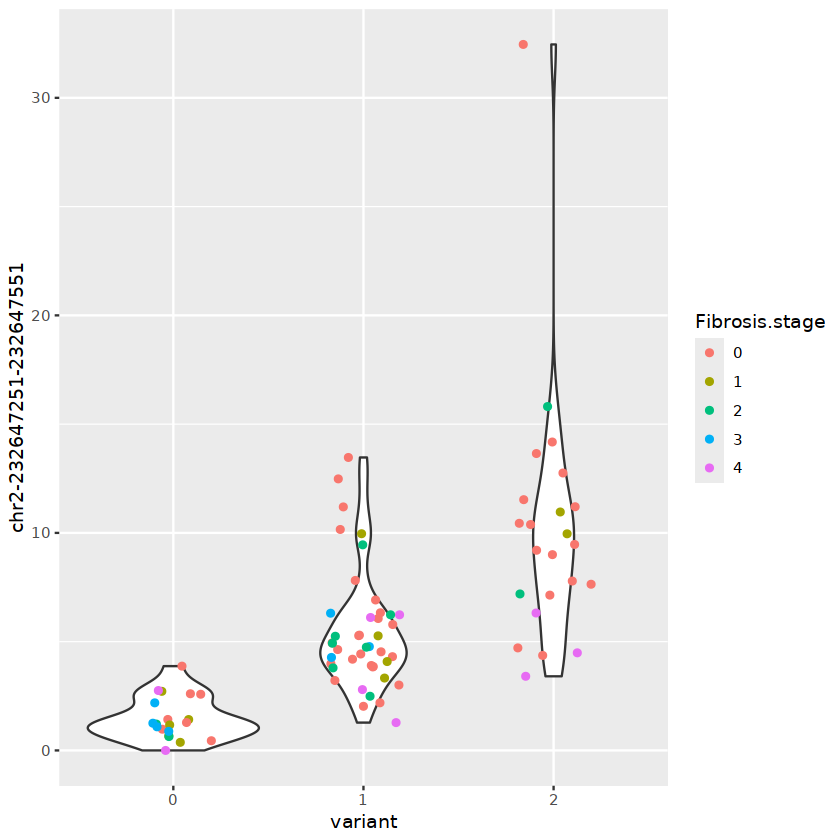

In [67]:
plot.data <- test.data
plot.data$variant <- factor(plot.data$variant, levels=0:2)
plot.data$Fibrosis.stage <- factor(plot.data$Fibrosis.stage, levels=0:4)

ggplot(plot.data, aes(x=variant, y=`chr2-232647251-232647551`)) + geom_violin() +
    geom_jitter(aes(color=Fibrosis.stage), width=.2)

# KRT8

In [2]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)

In [3]:
RNA.cov <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/covariates/Hepatocytes_perdonor.RNA.covariates.tsv')
RNA.cov <- t(RNA.cov) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
dim(RNA.cov)
head(RNA.cov)

[1] 86 32

,donor,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,feature.PC2,feature.PC3,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL160042,1,-0.98046310,-0.79714000,0,2,1,-93.36481,22.83019,-19.339760,⋯,-0.0111287,0.00380533,0.03954220,-0.006265730,-0.00386021,0.00771307,-1.75643e-03,-0.00687415,0.010761400,9.66876e-03
2,HL170046,1,0.42981569,2.13084844,1,3,1,-99.63055,56.33456,-4.224733,⋯,-0.0129588,0.02662470,-0.00340496,0.018265600,-0.00287539,-0.01398610,1.23325e-04,0.00230401,-0.000287042,3.55590e-03
3,HL190326,1,-0.46088670,-0.83281495,0,2,1,-60.29139,52.91906,28.059599,⋯,-0.0147062,-0.01295160,0.07529630,-0.023607700,-0.00132704,-0.00595419,-4.31907e-05,-0.00304233,0.014321600,1.92004e-04
4,HL160029,1,-0.01553551,-0.14177796,0,1,1,-79.17290,76.26758,11.350735,⋯,-0.0104861,0.00707262,0.03083550,0.000670898,-0.00198687,0.01476340,-3.75507e-03,-0.00198251,0.009025750,8.66651e-04
5,HL170060,1,0.20714009,-0.28183517,2,4,1,-50.97397,33.37821,-45.973181,⋯,-0.0123151,0.02658660,-0.00395044,0.017962300,-0.00193481,-0.01443590,-5.57276e-04,0.00147937,-0.000147571,1.69406e-05
6,HL210120,2,0.28136529,-0.02550406,3,4,1,-95.66030,-13.40454,-17.995776,⋯,-0.0117391,0.02623390,-0.00275870,0.017713800,-0.00230536,0.00284170,-2.35794e-03,0.00316974,-0.000331108,1.50624e-03


In [4]:
RNA.counts <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/counts/Hepatocytes_perdonor.RNA.INT.bed')

dim(RNA.counts)
head(RNA.counts)

[1] 20235    90

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,⋯,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90
,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1,133722,133723,AL627309.1,-1.6227112,0.5344601,-1.10897293,-1.2240583,0.60299558,-0.1906023,⋯,0.8710608,-1.8946444,-0.2805315,-2.5232398,-0.01457394,-1.3581421,0.3417246,-0.0437342,1.0565923,0.7887938
2,chr1,173861,173862,AL627309.5,-1.4354364,0.7115489,0.34172462,-0.6029956,-0.01457394,1.0565923,⋯,-0.1610005,-1.1089729,-0.3417246,-0.0437342,-0.22037207,-0.8710608,-1.2240583,-0.6383347,1.6227112,0.0437342
3,chr1,778746,778747,LINC01409,-1.4354364,-0.9596939,-1.35814208,-1.0565923,-0.04373420,0.3727933,⋯,0.6029956,-2.5232398,-0.2805315,0.1315391,-0.13153913,1.2240583,1.5224076,1.6227112,-0.6744898,0.4683492
4,chr1,825137,825138,LINC01128,-0.5011308,1.4354364,1.00696106,0.9596939,-0.07293170,0.2203721,⋯,0.6383347,-0.1610005,-0.9144792,0.3109825,-0.82922563,2.1097056,0.0437342,-0.8710608,-0.2503385,-0.3109825
5,chr1,827521,827522,LINC00115,-1.2240583,-1.7426467,-1.89464435,-1.1645874,-0.13153913,-0.8710608,⋯,0.6744898,0.1906023,0.1021915,-0.8292256,2.10970561,0.5344601,1.2240583,-0.4042260,-0.2503385,0.7496121
6,chr1,876902,876903,FAM41C,-1.1089729,-0.9596939,-0.01457394,-0.6744898,-1.89464435,1.0565923,⋯,1.0069611,1.5224076,-0.1315391,-1.5224076,0.28053149,0.7115489,1.1089729,0.4683492,-0.1021915,0.4360634


In [5]:
vcf.df <- data.table::fread('/nfs/lab/tscc/welison/FNIH.Liver/genotypes/241009_WE_class_matrix.rsID.tsv')
vcf.df <- tibble::column_to_rownames(vcf.df, 'V1')


#rownames(vcf.df) <- NULL
#vcf.df <- tibble::column_to_rownames(vcf.df, 'ID')

dim(vcf.df)
head(vcf.df)

Warning message in data.table::fread("/nfs/lab/tscc/welison/FNIH.Liver/genotypes/241009_WE_class_matrix.rsID.tsv"):
“Detected 87 column names but the data has 88 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


[1] 5492117      87

,ID,HL170044,HL200529,HL230212,HL220405,HL160017,HL170064,HL220402,HL150015,HL181029,⋯,HL170066,HL180071,HL170060,HL211122,HL221215,HL210806,HL190606,HL191216,HL210120,HL181010
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
chr10:116162:A:C,rs11594819,1,1,0,1,0,0,1,1,1,⋯,1,1,2,1,0,2,1,2,2,0
chr10:125824:C:G,rs72770958,1,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr10:132494:T:G,rs7089889,2,1,2,1,2,2,2,2,1,⋯,0,1,1,1,2,2,1,1,1,2
chr10:136160:C:T,rs73581705,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1
chr10:142865:A:G,rs12146291,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1
chr10:155638:G:A,rs17156310,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1


In [6]:
RNA.feat.counts <- filter(RNA.counts, V4=='KRT8') %>%
    select(-V1, -V2, -V3) %>%
    tibble::column_to_rownames('V4')
colnames(RNA.feat.counts) <- RNA.cov$donor
RNA.feat.counts <- t(RNA.feat.counts) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
RNA.feat.counts

donor,KRT8
<chr>,<dbl>
HL160042,-0.0729317
HL170046,0.6744898
HL190326,-1.0565923
HL160029,-1.0069611
HL170060,-1.1645874
HL210120,1.2882056
HL200925,-0.6029956
HL230316,1.8946444
HL220825,-0.6744898


In [7]:
RNA.snp.df <- filter(vcf.df, ID=='rs4919741') %>%
    select(-ID) 
rownames(RNA.snp.df) <- 'variant'
RNA.snp.df <- t(RNA.snp.df) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
#RNA.snp.df$variant <- factor(RNA.snp.df$variant, levels=0:2)
RNA.snp.df

donor,variant
<chr>,<int>
HL170044,1
HL200529,1
HL230212,1
HL220405,1
HL160017,1
HL170064,2
HL220402,1
HL150015,2
HL181029,0


In [8]:
inner_join(RNA.snp.df, RNA.feat.counts) %>%
    mutate(variant=factor(variant, levels=0:2))

Joining with `by = join_by(donor)`


donor,variant,KRT8
<chr>,<fct>,<dbl>
HL170044,1,-0.3109825
HL200529,1,-0.1610005
HL230212,1,-0.9596939
HL220405,1,-1.2240583
HL160017,1,-0.7887938
HL170064,2,-0.1906023
HL220402,1,2.1097056
HL150015,2,-0.6383347
HL181029,0,0.4360634


Joining with `by = join_by(donor)`


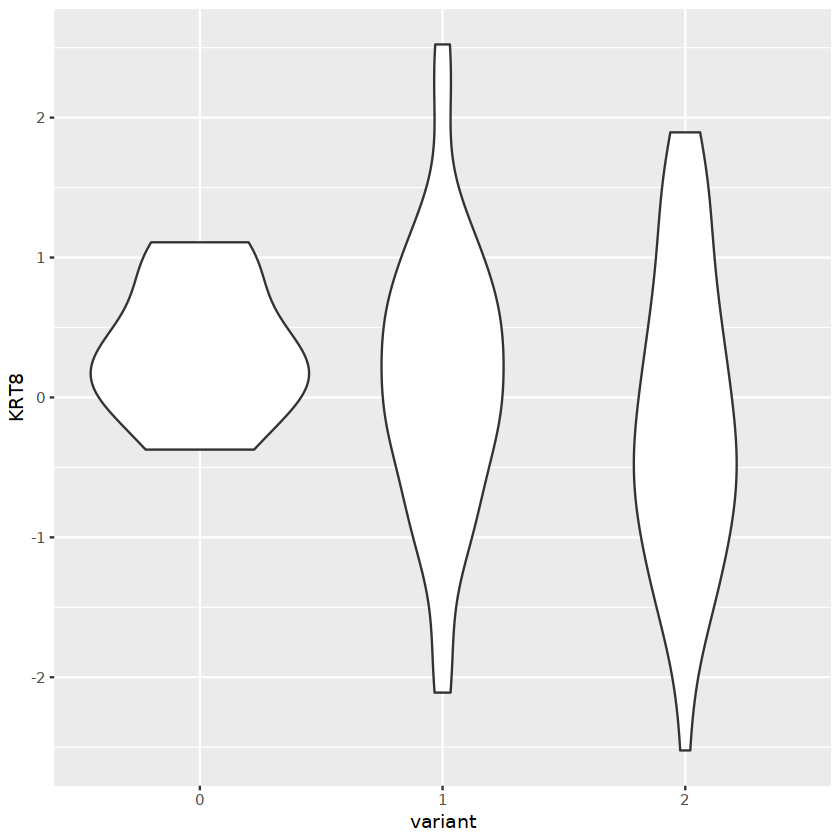

In [9]:
inner_join(RNA.snp.df, RNA.feat.counts) %>%
    mutate(variant=factor(variant, levels=0:2)) %>%
    ggplot(aes(x=variant, y=KRT8)) + geom_violin()

In [10]:
broom::tidy(lm(KRT8~variant, data = inner_join(RNA.snp.df, RNA.feat.counts)))

Joining with `by = join_by(donor)`


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.3642281,0.2634404,1.382583,0.1704576
variant,-0.2526098,0.1670031,-1.512605,0.1341334


In [11]:
test.data <- inner_join(RNA.snp.df, RNA.feat.counts) %>%
    inner_join(RNA.cov)
dim(test.data)
head(test.data)

Joining with `by = join_by(donor)`
Joining with `by = join_by(donor)`


[1] 86 34

,donor,variant,KRT8,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL170044,1,-0.3109825,2,-0.01553551,0.11455315,0,1,2,-10.97471,⋯,-0.0128442,0.017314500,-0.00276722,0.01341930,-0.00297114,-0.03327060,0.005593500,-0.007237180,0.003674560,-0.00228430
2,HL200529,1,-0.1610005,2,1.09784249,0.33388803,1,3,4,35.75990,⋯,-0.0101794,0.003793630,0.04251670,-0.00601031,-0.00585492,0.01142840,-0.000537141,-0.026803600,0.419668000,-0.54326300
3,HL230212,1,-0.9596939,2,0.65249129,0.03527549,1,3,3,55.22479,⋯,-0.0115252,0.002709290,0.04027980,-0.00646665,-0.00351872,0.00984427,-0.001876060,-0.002809980,0.007649630,0.00898169
4,HL220405,1,-1.2240583,2,-1.05468830,-0.81431682,0,2,4,72.83281,⋯,-0.0129373,0.027256000,-0.00437228,0.01950440,-0.00512447,-0.02138940,0.001285220,0.002518370,-0.025815600,0.01340040
5,HL160017,1,-0.7887938,2,-1.20313870,-1.04818594,2,4,4,38.41884,⋯,-0.0127687,0.026879400,-0.00358643,0.01741510,-0.00204888,-0.01008540,-0.001203540,0.000274721,-0.000784055,-0.00173246
6,HL170064,2,-0.1906023,2,1.39474329,0.67346069,1,3,3,27.00254,⋯,0.0436429,0.000511416,0.00306145,0.00354503,0.00831225,-0.01237850,-0.025290500,0.000778331,-0.018317700,-0.00823998


In [12]:
colnames(test.data)

[1] "donor"          "variant"        "KRT8"           "Gender"        
 [5] "Age.scaled"     "BMI.scaled"     "Fibrosis.stage" "condition"     
 [9] "batch"          "feature.PC1"    "feature.PC2"    "feature.PC3"   
[13] "feature.PC4"    "feature.PC5"    "feature.PC6"    "feature.PC7"   
[17] "feature.PC8"    "feature.PC9"    "feature.PC10"   "feature.PC11"  
[21] "feature.PC12"   "feature.PC13"   "feature.PC14"   "feature.PC15"  
[25] "genotype.PC1"   "genotype.PC2"   "genotype.PC3"   "genotype.PC4"  
[29] "genotype.PC5"   "genotype.PC6"   "genotype.PC7"   "genotype.PC8"  
[33] "genotype.PC9"   "genotype.PC10"

In [13]:
broom::tidy(lm(KRT8~variant + Gender + Age.scaled + BMI.scaled + condition + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * condition, data = test.data))
broom::tidy(lm(KRT8~variant + Gender + Age.scaled + BMI.scaled + Fibrosis.stage + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10 + variant * Fibrosis.stage, data = test.data))

term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.081275414,1.0983183,0.07399988,0.9412277
variant,-0.354200638,0.3996106,-0.88636455,0.3785451
Gender,-0.357629044,0.2532148,-1.41235426,0.1624060
Age.scaled,-0.087782161,0.1293354,-0.67871708,0.4996206
BMI.scaled,-0.002224108,0.1249851,-0.01779499,0.9858545
condition,0.138972513,0.2536602,0.54786885,0.5855759
batch,-0.117701562,0.1202947,-0.97844316,0.3313234
genotype.PC1,-1.848568664,28.6536353,-0.06451428,0.9487500
genotype.PC2,-8.680274622,11.9600345,-0.72577337,0.4704683


term,estimate,std.error,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.08328650,0.9361894,0.08896330,0.92937257
variant,-0.23633255,0.2131072,-1.10898445,0.27134367
Gender,-0.31368656,0.2411835,-1.30061395,0.19778118
Age.scaled,-0.12216277,0.1281137,-0.95354959,0.34368910
BMI.scaled,0.05041302,0.1215200,0.41485369,0.67955497
Fibrosis.stage,0.10285223,0.1737598,0.59192174,0.55586596
batch,-0.09471820,0.1182471,-0.80101909,0.42591061
genotype.PC1,-0.37109208,28.0126324,-0.01324731,0.98946927
genotype.PC2,-10.46964206,11.6413779,-0.89934732,0.37164147


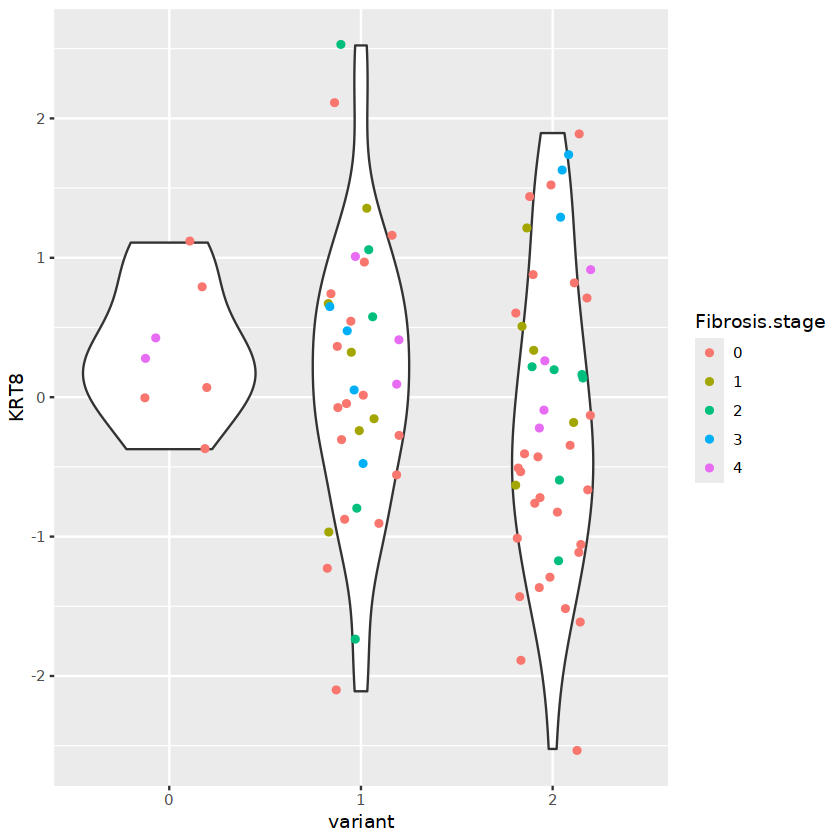

In [14]:
plot.data <- test.data
plot.data$variant <- factor(plot.data$variant, levels=0:2)
plot.data$Fibrosis.stage <- factor(plot.data$Fibrosis.stage, levels=0:4)

ggplot(plot.data, aes(x=variant, y=KRT8)) + geom_violin() +
    geom_jitter(aes(color=Fibrosis.stage), width=.2)

In [15]:
H3K27me3.cov <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/covariates/Hepatocytes_perdonor.H3K27me3.covariates.tsv')
H3K27me3.cov <- t(H3K27me3.cov) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
dim(H3K27me3.cov)
head(H3K27me3.cov)

[1] 86 32

,donor,Gender,Age.scaled,BMI.scaled,Fibrosis.stage,condition,batch,feature.PC1,feature.PC2,feature.PC3,⋯,genotype.PC1,genotype.PC2,genotype.PC3,genotype.PC4,genotype.PC5,genotype.PC6,genotype.PC7,genotype.PC8,genotype.PC9,genotype.PC10
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HL210120,2,0.2813653,-0.02550406,3,4,1,-102.03466891,241.04449,-28.81846,⋯,-0.0117391,0.02623390,-0.00275870,0.01771380,-0.002305360,0.00284170,-0.002357940,0.00316974,-0.000331108,1.50624e-03
2,HL160042,1,-0.9804631,-0.79714000,0,2,1,-145.49654876,-64.39608,54.73894,⋯,-0.0111287,0.00380533,0.03954220,-0.00626573,-0.003860210,0.00771307,-0.001756430,-0.00687415,0.010761400,9.66876e-03
3,HL210521,1,1.0236173,-0.15631220,0,2,2,0.02719317,-112.91903,-18.59554,⋯,-0.0118909,0.02617860,-0.00262999,0.01790570,-0.002146130,-0.00893063,-0.001638330,0.00601711,-0.000684103,1.46816e-03
4,HL200707,1,0.9493921,0.63117927,0,2,1,-57.24839108,-206.70114,89.82006,⋯,-0.0124922,0.02662110,-0.00389152,0.01712730,-0.002147750,-0.00671683,-0.001741690,0.00205386,-0.000945388,1.43404e-03
5,HL170060,1,0.2071401,-0.28183517,2,4,1,-148.18119547,-104.73710,74.81439,⋯,-0.0123151,0.02658660,-0.00395044,0.01796230,-0.001934810,-0.01443590,-0.000557276,0.00147937,-0.000147571,1.69406e-05
6,HL230316,1,0.8009417,-0.34789989,0,1,1,-129.80868483,-32.73610,-24.07604,⋯,0.0465268,-0.00120517,0.00324099,0.00261824,-0.000558042,-0.01247550,-0.036937800,-0.00011814,-0.013126900,-9.85961e-03


In [16]:
H3K27me3.counts <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/bins_mtx/Hepatocytes_H3K27me3_donor.15kb_bin.rpm.xls')
colnames(H3K27me3.counts) <- str_extract(colnames(H3K27me3.counts), "HL[0-9]*")

dim(H3K27me3.counts)
head(H3K27me3.counts)

[1] 183028     86

,HL150001,HL150009,HL150013,HL150015,HL160017,HL160022,HL160026,HL160029,HL160030,HL160032,⋯,HL221006,HL221019,HL221119,HL221201,HL221215,HL230212,HL230302,HL230316,HL230324,HL230325
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
chr1:0-15000,14,32,4,168,154,0,40,28,32,6,⋯,24,22,6,46,24,36,12,44,36,158
chr1:15000-30000,4,0,2,6,12,2,0,10,2,0,⋯,0,0,0,4,0,2,0,2,2,8
chr1:30000-45000,4,2,2,6,8,2,2,4,0,0,⋯,0,2,0,0,0,2,0,4,0,4
chr1:45000-60000,0,2,2,44,48,0,16,6,18,2,⋯,8,12,2,10,8,10,2,38,18,22
chr1:60000-75000,6,4,0,68,48,0,14,6,10,0,⋯,18,6,1,12,6,16,4,36,15,38
chr1:75000-90000,8,0,4,199,76,0,24,4,13,2,⋯,36,9,1,34,12,33,16,45,37,62


In [17]:
#rownames(H3K27me3.counts)[str_detect(rownames(H3K27me3.counts), 'chr12:528')]
#chr12:52884454-52885453
#chr12:52875000-52890000
#chr12:52875000-52890000

[1] "chr12:5280000-5295000"   "chr12:52800000-52815000"
[3] "chr12:52815000-52830000" "chr12:52830000-52845000"
[5] "chr12:52845000-52860000" "chr12:52860000-52875000"
[7] "chr12:52875000-52890000" "chr12:52890000-52905000"

ERROR: Error in eval(expr, envir, enclos): object 'chr12' not found


In [ ]:
H3K27me3.feat.counts <- H3K27me3.counts['chr12:52890000-52905000',]
colnames(H3K27me3.feat.counts) <- H3K27me3.cov$donor
H3K27me3.feat.counts <- t(H3K27me3.feat.counts) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
H3K27me3.feat.counts

In [ ]:
H3K27me3.snp.df <- filter(vcf.df, ID=='rs4919741') %>%
    select(-ID) 
rownames(H3K27me3.snp.df) <- 'variant'
H3K27me3.snp.df <- t(H3K27me3.snp.df) %>%
    as.data.frame() %>%
    tibble::rownames_to_column(var='donor')
#H3K27me3.snp.df$variant <- factor(H3K27me3.snp.df$variant, levels=0:2)
H3K27me3.snp.df

In [ ]:
inner_join(H3K27me3.snp.df, H3K27me3.feat.counts)

In [ ]:
inner_join(H3K27me3.snp.df, H3K27me3.feat.counts) %>%
    mutate(variant =factor(variant, levels=0:2)) %>%
    ggplot(aes(x=variant, y=`chr12:52890000-52905000`)) + geom_violin()

In [ ]:
broom::tidy(lm(`chr12:52890000-52905000`~variant, data = inner_join(H3K27me3.snp.df, H3K27me3.feat.counts)))

In [ ]:
test.data <- inner_join(H3K27me3.snp.df, H3K27me3.feat.counts) %>%
    inner_join(H3K27me3.cov)
dim(test.data)
head(test.data)

In [ ]:
colnames(test.data)

In [ ]:
broom::tidy(lm(`chr12:52890000-52905000`~variant + Gender + Age.scaled + BMI.scaled + condition + batch + genotype.PC1 + genotype.PC2 + genotype.PC3 + genotype.PC4 + genotype.PC5 + genotype.PC6 + genotype.PC7 + genotype.PC8 + genotype.PC9 + genotype.PC10, data = test.data))